In [105]:
%pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [106]:
x1 = [10,8,13,9,11,14,6,4,12,7,5]
y1 = [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68] 

x2 = [10,8,13,9,11,14,6,4,12,7,5]
y2 = [9.14,8.14,8.47,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]

x3 = [8,8,8,8,8,8,8,8,8,8,19]
y3 = [6.58,5.76,7.71,8.84,8.47,7.04,5.25,5.56,7.91,6.89,12.50]

In [107]:
def media(vetor): return sum(vetor) / len(vetor)

def calcula_produto_ambos(vetX, vetY):
    # parte de cima 
    produto_ambos = 0
    for i in range(len(vetX)):
        x = vetX[i]
        y = vetY[i]

        produto_ambos = produto_ambos + ((x - media(vetX)) * (y - media(vetY)))

    return produto_ambos

def calcula_produto(vet):
    produto = 0
    for i in range(len(vet)):
        x = vet[i]

        produto = produto + ((x - media(vet)) ** 2)

    return produto

In [108]:
from math import sqrt


def correlacao(vetX, vetY):
    # parte de cima
    produto_ambos = calcula_produto_ambos(vetX, vetY)

    # parte de baixo 
    produto_x = calcula_produto(vetX)
    produto_y = calcula_produto(vetY)
    raiz_quadrada_produtos = sqrt(produto_x * produto_y)

    return produto_ambos / raiz_quadrada_produtos

In [109]:
def betaUm(vetX, vetY):
    return calcula_produto_ambos(vetX, vetY) / calcula_produto(vetX)

def betaZero(vetX, vetY, betaUm):
    return media(vetY) - (betaUm * media(vetX))

def regressao(vetX, vetY, varIndependente):
    return betaZero(vetX, vetY, betaUm(vetX, vetY)) + (betaUm(vetX, vetY) * varIndependente)

In [110]:
print("c", correlacao(x1, y1))
print("b1", betaUm(x1, y1))
print("b0", betaZero(x1, y1, betaUm(x1, y1)))

print("=" * 10)

print("c", correlacao(x2, y2))
print("b1", betaUm(x2, y2))
print("b0", betaZero(x2, y2, betaUm(x2, y2)))

print("=" * 10)

print("c", correlacao(x3, y3))
print("b1", betaUm(x3, y3))
print("b0", betaZero(x3, y3, betaUm(x3, y3)))

c 0.81642051634484
b1 0.5000909090909091
b0 3.0000909090909085
c 0.8061168716933017
b1 0.4901818181818182
b0 3.0647272727272714
c 0.8165214368885029
b1 0.4999090909090909
b0 3.0017272727272726


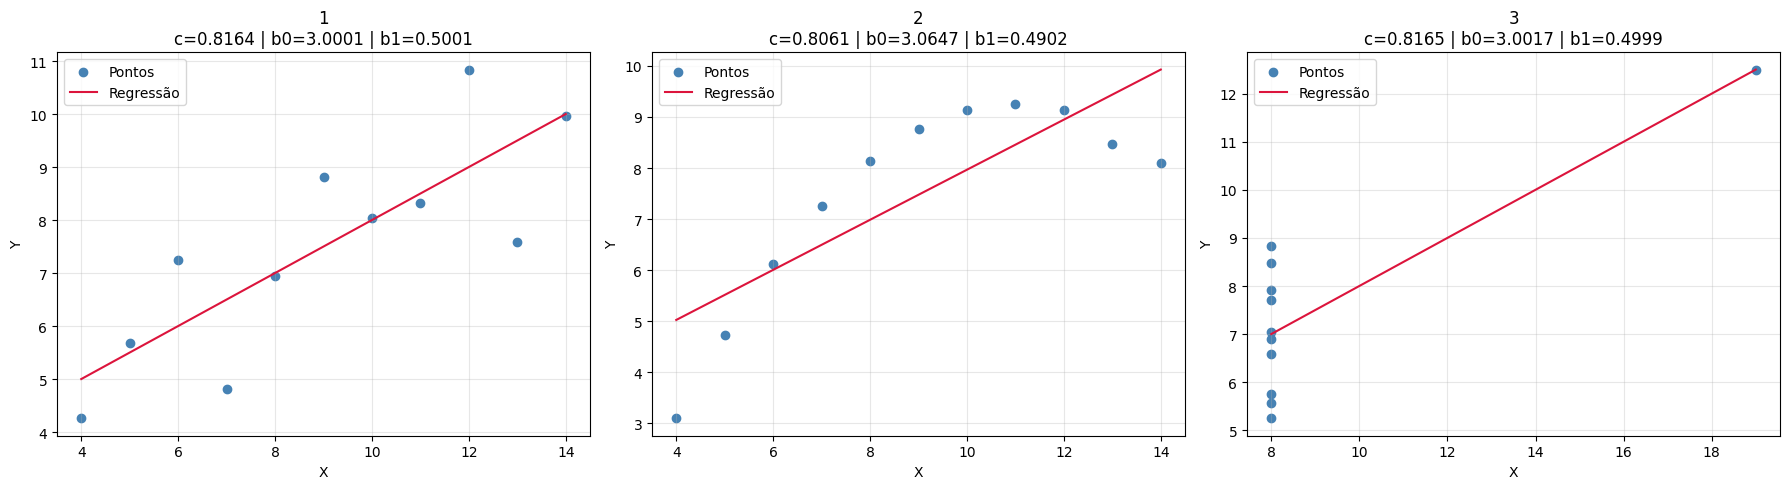

In [111]:
import matplotlib.pyplot as plt

dados = [("1", x1, y1), ("2", x2, y2), ("3", x3, y3)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, x, y) in zip(axes, dados):
    c = correlacao(x, y)
    b1 = betaUm(x, y)
    b0 = betaZero(x, y, b1)

    ax.scatter(x, y, color="steelblue", label="Pontos")

    x_linha = [min(x), max(x)]
    y_linha = [b0 + b1 * xi for xi in x_linha]
    ax.plot(x_linha, y_linha, color="crimson", label="Regressão")

    ax.set_title(f"{nome}\nc={c:.4f} | b0={b0:.4f} | b1={b1:.4f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()